In [1]:
import tensorflow as tf
print(tf.__version__)

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0


### Regression analysis

Regression analysis is a statistical method used to examine the relationship between a dependent variable (outcome) and one or more independent variables (predictors). It is widely applied in fields like machine learning, data science, economics, healthcare, and marketing to make predictions and understand variable relationships.

The primary goal of regression analysis is to model the relationship between variables, assess its strength, and use the model for prediction. It is a supervised learning technique, meaning it uses labeled data (training and testing datasets) to build and validate the model.

### Architecture of a Regression model

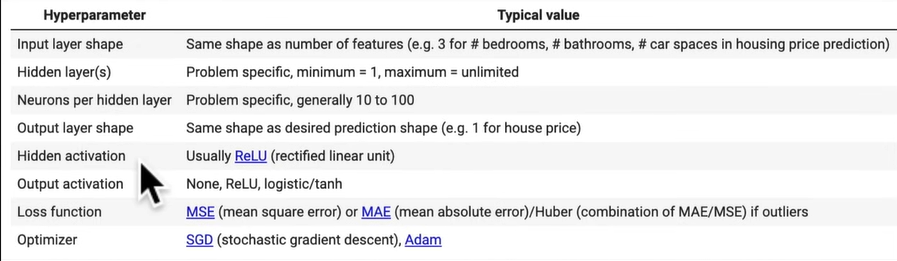

In [2]:
#creating data to view and fit
import numpy as np
import matplotlib .pyplot as plt

X = np.array([-7,-4,-1,2,5,8,11,14])
y = np.array([3,6,9,12,15,18,21,24])

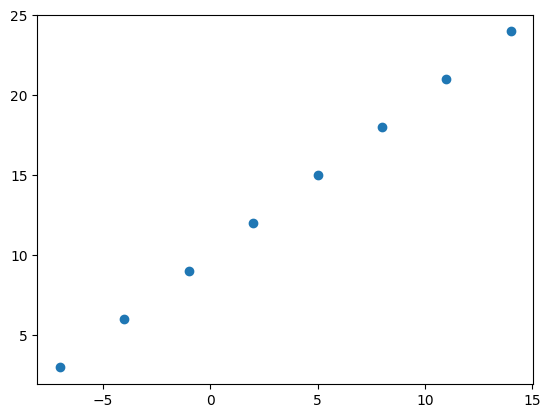

In [3]:
plt.scatter(X,y)

In [4]:
#verify the relation 
y == X + 10 

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [5]:
#Input and Output shapes (New Data)
house_info = tf.constant(["bedroom","bathroom","gatage"])
house_price = tf.constant([939700])
house_info,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'gatage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [6]:
X.shape,y.shape

((8,), (8,))

In [7]:
#Turn the Numpy array into Tensorflow tensor
X = tf.cast(tf.constant(X),dtype=float)
y = tf.cast(tf.constant(y),dtype=float)
X,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [8]:
X.shape,y.shape

(TensorShape([8]), TensorShape([8]))

In [9]:
X.ndim,y.ndim

(1, 1)

You need to convert your 1D array into a 2D column matrix so its shape becomes (n, 1).

Why?

A Dense layer mathematically refuses to accept 1-Dimensional data. It always expects data in at least 2 Dimensions: (Batch_Size, Number_of_Features).

In [10]:
X = X[:,tf.newaxis]
X

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]], dtype=float32)>

In [11]:
X.ndim

2

Alternative Fixes:
If your X data is currently a NumPy array instead of a TensorFlow constant, you can also fix it using standard NumPy reshaping:

X = X.reshape(-1, 1)

X = np.expand_dims(X, axis=-1)


### Steps in modelling with TensorFlow


Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).<br>
<br>

2. **Compiling a model** - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).<br>
<br>

3. **Fitting a model** - letting the model try to find patterns in the data (how does X get to y).<br>

In [12]:
# set random seed
tf.random.set_seed(42)

#1. Create a model using the Sequential API

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the Model 

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(), #also can be written like optimizer = "sgd"
              metrics=["mae"])

#3. Fit the model
model.fit(X,y,epochs=3)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - loss: 16.1969 - mae: 16.1969
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 15.9156 - mae: 15.9156
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 15.6343 - mae: 15.6343


In [13]:
#Also can be written 
#model = tf.keras.Sequential()
#model.add(tf.keras.layers.Dense(1))

In [14]:
# model.predict(17) 
#Throw an Error

#### Imp Error
ValueError: Unrecognized data type: x=17 (of type <class 'int'>)

TensorFlow is highly optimized to run on Tensors and NumPy arrays, not standard Python integers. 

Furthermore, as we learned with the Dense layer math, a model always expects data in batches (a 2D structure), even if you are only asking it to predict a single number.

When you pass 17, you are passing a 0-Dimensional scalar. The model is looking for a 2-Dimensional batch: (Batch_Size, Features).

**The Solution**
You simply need to wrap your number in a 2D list (double brackets or use np.array()), which instantly gives it a shape of (1, 1): 1 example, 1 feature.

Here are the three acceptable ways to pass data to .predict()

In [15]:
#Make a prediction using our model
prediction = model.predict(np.array([17]))
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[-8.46123]], dtype=float32)

### Improving a model

To improve our model, we alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
<br>

2. **Compiling a model** - you might want to choose optimization function or perhaps change the learning rate of the optimization function.
<br>

3. **Fitting a model** - perhaps you could fit a model for more epochs (leave it training for longer) or on more data (give the model more examples to learn from).

In [16]:
# Creating a Improve Model

new_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=(1,)),
])

new_model.compile(loss=tf.keras.losses.mae,
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
                  metrics=["mae"])

new_model.fit(X,y,epochs=500,verbose=0)

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
pred = new_model.predict(np.array([17]))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[26.877003]], dtype=float32)

### Evaluating a model

When it comes to evaluation, you'll want to remember the words: "visualize".

This is because you're probably better looking at something (doing) than you are thinking about something.

It's a good idea to visualize:

The data - what data are you working with? What does it look like?

The model itself - what does the architecture look like? What are the different shapes?

The training of a model - how does a model perform while it learns?

The predictions of a model - how do the predictions of a model line up against the ground truth (the original labels)?

In [18]:
X = tf.range(-100,100,4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [19]:
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

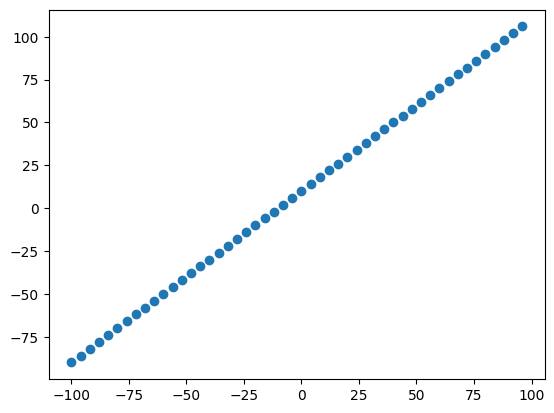

In [20]:
plt.scatter(X,y)

### Split data into training/test set

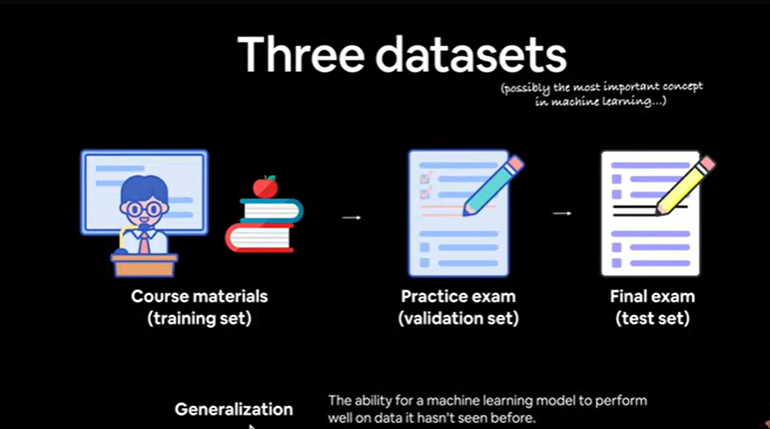

In [21]:
len(X)

50

In [22]:
#Split the Data in 80/20 part (Train/Test) 
X_train = X[:40]
y_train = y[:40]


X_test = X[40:]
y_test = y[40:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

#### Another Way to split data

STEP 1: Split off the Test Set (Hold out 15%)

This splits the data into 85% for Training/Validation, and 15% strictly for Testing

**X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)**

STEP 2: Split the remaining 85% into Train and Validation

We split the temporary data again (taking 15% of the original total for validation)

**X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)**


In [23]:
#Model Summary
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

Calling summary() on our model shows us the layers it contains, the output shape and the number of parameters.

**Total params** - total number of parameters in the model.

**Trainable parameters** - these are the parameters (patterns) the model can update as it trains.

**Non-trainable parameters** - these parameters aren't updated during training (this is typical when you bring in the already learned patterns from other models during transfer learning).

### Verbose

verbose is the "chattiness" setting of your code. It tells the computer exactly how much information it is allowed to print to your screen while it is working on a long task.

When you train a model in TensorFlow using model.fit(), you can set verbose to three different numbers:

1. verbose=1 (The Default: "Talkative")
If you don't type anything, TensorFlow assumes verbose=1.

What it does: It prints an animated progress bar for every single epoch, showing you exactly how many batches are done, the estimated time remaining, and the live loss/accuracy scores.

What it looks like:
Epoch 1/500
14/14 [===========>...] - ETA: 0s - loss: 2.15 - mae: 1.05

When to use it: When you are training a new model and want to actively watch the loss go down in real-time to make sure it is actually learning.

2. verbose=2 (The Middle Ground: "Brief")
What it does: It removes the animated progress bar and just prints one single summary line after the entire epoch is completely finished.

What it looks like:
Epoch 1/500 - 0s - loss: 2.15 - mae: 1.05

When to use it: When you are running code on a remote cloud server. Animated progress bars can sometimes break cloud terminal windows by printing thousands of weird characters. verbose=2 keeps it clean and readable.

3. verbose=0 (Silent Mode)
What it does: Absolutely nothing. It gags the output completely. The model will train quietly in the background and only return the prompt when it is 100% finished.


In [24]:
model.fit(X,y,epochs=10,verbose=0)

In [25]:
model.fit(X,y,epochs=10,verbose=1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.4885 - mae: 11.4885
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.0462 - mae: 11.0462
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10.3042 - mae: 10.3042
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9.8974 - mae: 9.8974
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.7546 - mae: 9.7546
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.6118 - mae: 9.6118 
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 10.8342 - mae: 10.8342
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.6995 - mae: 9.6995
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6787 - mae: 9.6787
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.6579 - mae: 9.6579


In [26]:
model.fit(X,y,epochs=10,verbose=2)

Epoch 1/10
2/2 - 0s - 37ms/step - loss: 9.6371 - mae: 9.6371
Epoch 2/10
2/2 - 0s - 26ms/step - loss: 9.6162 - mae: 9.6162
Epoch 3/10
2/2 - 0s - 22ms/step - loss: 9.5954 - mae: 9.5954
Epoch 4/10
2/2 - 0s - 20ms/step - loss: 9.5746 - mae: 9.5746
Epoch 5/10
2/2 - 0s - 13ms/step - loss: 9.4021 - mae: 9.4021
Epoch 6/10
2/2 - 0s - 25ms/step - loss: 11.3225 - mae: 11.3225
Epoch 7/10
2/2 - 0s - 16ms/step - loss: 11.2887 - mae: 11.2887
Epoch 8/10
2/2 - 0s - 20ms/step - loss: 11.2549 - mae: 11.2549
Epoch 9/10
2/2 - 0s - 21ms/step - loss: 10.7885 - mae: 10.7885
Epoch 10/10
2/2 - 0s - 21ms/step - loss: 10.0292 - mae: 10.0292


##### Evaluting our model's prediction with regression evaluation metrics

Three of the main metrics used for regression problems are:

**Mean absolute error (MAE)** - the mean difference between each of the predictions.

**Mean squared error (MSE)** - the squared mean difference between of the predictions (use if larger errors are more detrimental than smaller errors).

**Huber** - Combination of MSE and MAE. Less sensitive to outlier than MSE.


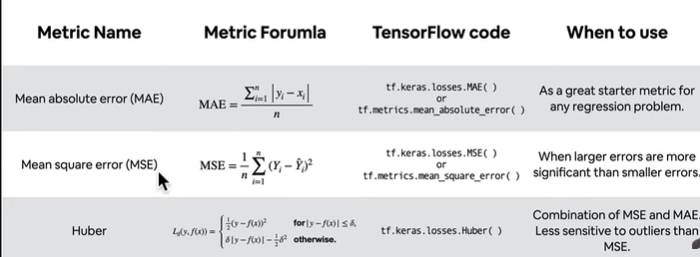


The lower each of these values, the better.

You can also use model.evaluate() which will return the loss of the model as well as any metrics setup during the compile step.

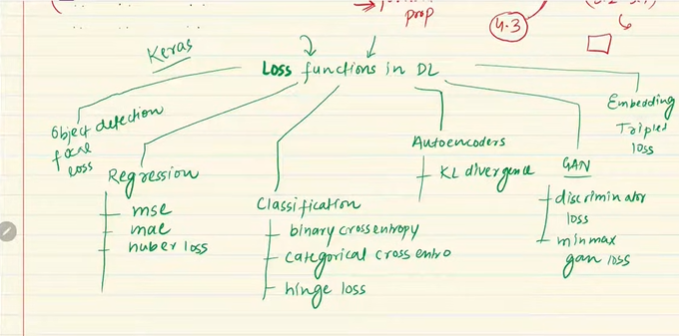

In [27]:
# first fit the X_train list for prediction
y_pred = new_model.predict(X_test)
y_pred


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[ 69.55066 ],
       [ 73.5203  ],
       [ 77.48995 ],
       [ 81.459595],
       [ 85.42924 ],
       [ 89.39888 ],
       [ 93.36852 ],
       [ 97.338165],
       [101.30781 ],
       [105.27745 ]], dtype=float32)

In [28]:
new_model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.5859 - mae: 0.5859


[0.5859428644180298, 0.5859428644180298]

In [32]:
# Calculate MAE
mae = tf.keras.losses.MAE(y_test,tf.constant(y_pred))
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.44934082, 0.47969818, 0.5100479 , 0.5404053 , 0.57076263,
       0.60112   , 0.63147736, 0.6618347 , 0.6921921 , 0.72254944],
      dtype=float32)>

In [33]:
#Check prediction list
y_pred = tf.constant(y_pred)
y_pred

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 69.55066 ],
       [ 73.5203  ],
       [ 77.48995 ],
       [ 81.459595],
       [ 85.42924 ],
       [ 89.39888 ],
       [ 93.36852 ],
       [ 97.338165],
       [101.30781 ],
       [105.27745 ]], dtype=float32)>

In [ ]:
# due to y_pred is different shape from y_test So We need to reduce(squeeze) the y_pred
y_pred = tf.squeeze(y_pred)

In [35]:
y_pred

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 69.55066 ,  73.5203  ,  77.48995 ,  81.459595,  85.42924 ,
        89.39888 ,  93.36852 ,  97.338165, 101.30781 , 105.27745 ],
      dtype=float32)>

In [ ]:
mae = tf.keras.losses.MAE(y_test,y_pred)
mae

<tf.Tensor: shape=(), dtype=float32, numpy=0.5859428644180298>

In [38]:
# Calculate MSE

mse = tf.keras.losses.MSE(y_test,y_pred)
mse

<tf.Tensor: shape=(), dtype=float32, numpy=0.3509315848350525>